 Logistic Regression Implementation

In [1]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, f1_score
import pandas as pd

Load the dataset

In [15]:
data = pd.read_csv("../../Data/cleaned_data_classification_all_decades.csv")

Normalize Data

In [16]:
from sklearn.preprocessing import StandardScaler

# Assuming 'data' is your DataFrame and 'target' is the name of your target variable
X = data.drop('target', axis=1)  # Features
y = data['target']  # Target variable
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [17]:
train, test = train_test_split(data, test_size=0.3, random_state=42)
X_train = train.drop('target', axis=1)
y_train = train['target']
X_test = test.drop('target', axis=1)
y_test = test['target']

In [18]:
#print feature names
print("Feature names:")
for i, feature in enumerate(X.columns):
    print(f"{i}: {feature}")
print("Number of features:", len(X.columns)
      )

Feature names:
0: instrumentalness
1: danceability
2: loudness
3: acousticness
4: valence
5: time_signature
Number of features: 6


In [9]:
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [25]:
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
# do it again with cv folds
cv_scores = cross_val_score(LogisticRegression(), X_train, y_train, cv=5, scoring='f1_weighted')
print("Cross-Validation F1 Scores:", cv_scores)
print("Average CV F1 Score:", cv_scores.mean())


Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      1826
           1       0.72      0.86      0.78      1732

    accuracy                           0.77      3558
   macro avg       0.78      0.77      0.77      3558
weighted avg       0.78      0.77      0.77      3558

Confusion Matrix:
[[1249  577]
 [ 241 1491]]
F1 Score: 0.7847368421052632
Cross-Validation F1 Scores: [0.77572577 0.78493898 0.77212574 0.77066104 0.7838945 ]
Average CV F1 Score: 0.777469205652922


In [5]:
# Logistic Regression Grid Search
from sklearn.model_selection import GridSearchCV
param_grid = {
    'C': [10, 100, 200, 300, 500],
    'solver': ['liblinear', 'lbfgs'],
    'l1_ratio': [0, 1],
    'max_iter': [100, 200, 500]
}
grid_search = GridSearchCV(LogisticRegression(), param_grid, cv=5, scoring='f1_weighted')
grid_search.fit(X_train, y_train)
print("Best Parameters:", grid_search.best_params_)
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test)
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix for Best Model:")
print(confusion_matrix(y_test, y_pred_best))
print("F1 Score for Best Model:", f1_score(y_test, y_pred_best))


KeyboardInterrupt: 

In [6]:
# apply the best model to the test set
best_params = {'C': 300, 'l1_ratio': 0, 'max_iter': 100, 'solver': 'lbfgs'}
best_model = LogisticRegression(**best_params)
best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)
print("Classification Report for Best Model:")
print(classification_report(y_test, y_pred_best))
print("Confusion Matrix for Best Model:")
print(confusion_matrix(y_test, y_pred_best))
print("F1 Score for Best Model:", f1_score(y_test, y_pred_best))
print("Accuracy Score for Best Model:", accuracy_score(y_test, y_pred_best))

Classification Report for Best Model:
              precision    recall  f1-score   support

           0       0.84      0.68      0.75      2730
           1       0.72      0.86      0.78      2607

    accuracy                           0.77      5337
   macro avg       0.78      0.77      0.77      5337
weighted avg       0.78      0.77      0.77      5337

Confusion Matrix for Best Model:
[[1854  876]
 [ 357 2250]]
F1 Score for Best Model: 0.7849293563579278
Accuracy Score for Best Model: 0.7689713322091062


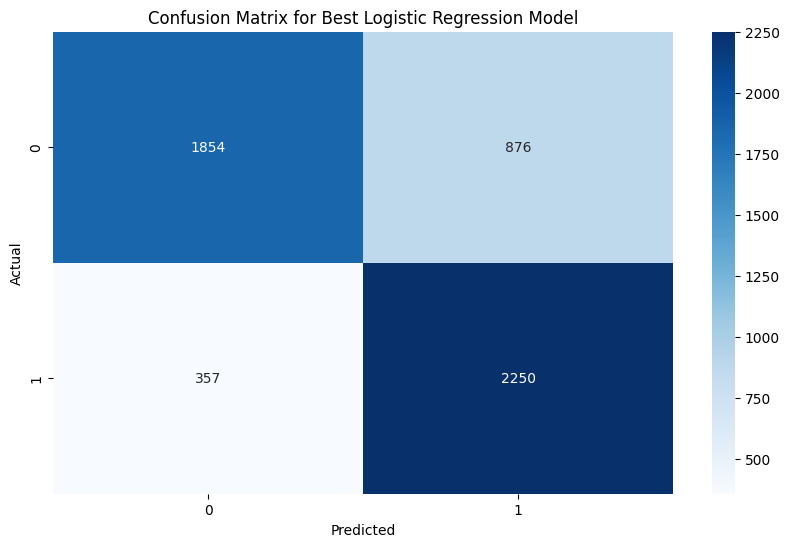

In [12]:
#plot classification results
from matplotlib import pyplot as plt
import seaborn as sns
plt.figure(figsize=(10, 6))
# Plot confusion matrix
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, cmap=plt.cm.Blues, fmt='g')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix for Best Logistic Regression Model')
plt.show()
